In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
PROJECT_PATH = '/content/drive/MyDrive/ReplayAttack_Project'
RAW_DATA_PATH = PROJECT_PATH + '/raw_dataset/4593128'  # root of extracted dataset
PROCESSED_PATH = PROJECT_PATH + '/processed'
MODELS_PATH = PROJECT_PATH + '/models'

import os
if not os.path.exists(PROCESSED_PATH):
    os.makedirs(PROCESSED_PATH)
print("Paths set again! RAW_DATA_PATH is:", RAW_DATA_PATH)

Paths set again! RAW_DATA_PATH is: /content/drive/MyDrive/ReplayAttack_Project/raw_dataset/4593128


In [ ]:
!pip install tensorflow opencv-python numpy

Preprocess Function

In [ ]:
import cv2
import numpy as np
import os

def extract_frames(video_path, every_n=5, img_size=(224, 224)):
    cap = cv2.VideoCapture(video_path)
    frames = []
    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_count % every_n == 0:
            frame = cv2.resize(frame, img_size)
            frames.append(frame)
        frame_count += 1
    cap.release()
    return np.array(frames) / 255.0  # normalize to 0-1

print("Extract frames function ready!")

Extract frames function ready!


Process Dataset Function (fixed for your structure)

In [ ]:
def process_dataset(base_path, set_name, attack_type='real', label=0, output_name='', max_frames=20):
    data = []
    labels = []

    if attack_type == 'real':
        folder_path = os.path.join(base_path, set_name, 'real')
        if not os.path.exists(folder_path):
            print(f"Error: Real folder not found: {folder_path}")
            return
        attack_subfolders = [folder_path]  # only one
    else:
        attack_subfolders = [
            os.path.join(base_path, set_name, 'attack', 'hand'),
            os.path.join(base_path, set_name, 'attack', 'fixed')
        ]

    for folder_path in attack_subfolders:
        if not os.path.exists(folder_path):
            print(f"Skipping missing folder: {folder_path}")
            continue
        for file in os.listdir(folder_path):
            video_path = os.path.join(folder_path, file)
            if os.path.isfile(video_path):
                cap = cv2.VideoCapture(video_path)
                frames = []
                frame_count = 0
                while cap.isOpened() and len(frames) < max_frames:
                    ret, frame = cap.read()
                    if not ret:
                        break
                    if frame_count % 5 == 0:  # every 5th frame
                        frame = cv2.resize(frame, (224, 224))
                        frames.append(frame)
                    frame_count += 1
                cap.release()

                if len(frames) > 0:
                    # Pad or truncate to exactly max_frames
                    while len(frames) < max_frames:
                        frames.append(frames[-1])  # repeat last frame
                    frames = frames[:max_frames]  # truncate if too many
                    data.append(np.array(frames) / 255.0)
                    labels.append(label)

    if len(data) > 0:
        data_array = np.array(data)  # shape: (num_videos, max_frames, 224, 224, 3)
        labels_array = np.array(labels)
        np.save(os.path.join(PROCESSED_PATH, f'{output_name}_data.npy'), data_array)
        np.save(os.path.join(PROCESSED_PATH, f'{output_name}_labels.npy'), labels_array)
        print(f"{output_name} processed and saved! ({len(data)} videos, fixed {max_frames} frames each)")
    else:
        print(f"No videos processed for {output_name}")

Run Processing (for all sets)


In [ ]:
# TRAIN
process_dataset(RAW_DATA_PATH, 'replayattack-train/train', 'real', 0, 'train_real')
process_dataset(RAW_DATA_PATH, 'replayattack-train/train', 'attack', 1, 'train_attack')

# DEV
process_dataset(RAW_DATA_PATH, 'replayattack-devel/devel', 'real', 0, 'dev_real')
process_dataset(RAW_DATA_PATH, 'replayattack-devel/devel', 'attack', 1, 'dev_attack')

# TEST
process_dataset(RAW_DATA_PATH, 'replayattack-test/test', 'real', 0, 'test_real')
process_dataset(RAW_DATA_PATH, 'replayattack-test/test', 'attack', 1, 'test_attack')

print("All processing completed!")

train_real processed and saved! (60 videos, fixed 20 frames each)
train_attack processed and saved! (300 videos, fixed 20 frames each)
dev_real processed and saved! (60 videos, fixed 20 frames each)
dev_attack processed and saved! (300 videos, fixed 20 frames each)
test_real processed and saved! (80 videos, fixed 20 frames each)
test_attack processed and saved! (400 videos, fixed 20 frames each)
All processing completed!


New Cell 6: Custom Video Data Generator (Memory-Safe)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import numpy as np
import os

# Parameters
IMG_SIZE = (224, 224)
MAX_FRAMES = 15  # reduced from 20 to save memory
BATCH_SIZE = 16  # small batch for low RAM

def video_frame_generator(video_paths, labels, batch_size=BATCH_SIZE, max_frames=MAX_FRAMES):
    while True:
        # Shuffle at start of epoch
        indices = np.arange(len(video_paths))
        np.random.shuffle(indices)
        video_paths = [video_paths[i] for i in indices]
        labels = [labels[i] for i in indices]

        for start in range(0, len(video_paths), batch_size):
            batch_paths = video_paths[start:start + batch_size]
            batch_labels = labels[start:start + batch_size]
            batch_frames = []
            batch_y = []

            for path, lbl in zip(batch_paths, batch_labels):
                cap = cv2.VideoCapture(path)
                frames = []
                frame_count = 0
                while cap.isOpened() and len(frames) < max_frames:
                    ret, frame = cap.read()
                    if not ret:
                        break
                    if frame_count % 5 == 0:
                        frame = cv2.resize(frame, IMG_SIZE)
                        frames.append(frame / 255.0)
                    frame_count += 1
                cap.release()

                # Pad or truncate
                while len(frames) < max_frames:
                    frames.append(frames[-1] if frames else np.zeros((224, 224, 3)))
                frames = frames[:max_frames]

                batch_frames.append(frames)
                batch_y.append(lbl)

            yield np.array(batch_frames), np.array(batch_y)

print("Custom generator ready!")

Custom generator ready!


New Cell 7: Collect Video Paths & Labels (Instead of .npy)

In [ ]:
def collect_video_paths_and_labels(base_path, set_name):
    real_paths = []
    attack_paths = []

    # Real
    real_folder = os.path.join(base_path, set_name, 'real')
    if os.path.exists(real_folder):
        real_paths = [os.path.join(real_folder, f) for f in os.listdir(real_folder) if f.endswith(('.mov', '.mp4'))]

    # Attack (hand + fixed)
    attack_hand = os.path.join(base_path, set_name, 'attack', 'hand')
    attack_fixed = os.path.join(base_path, set_name, 'attack', 'fixed')

    attack_paths = []
    for folder in [attack_hand, attack_fixed]:
        if os.path.exists(folder):
            attack_paths += [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(('.mov', '.mp4'))]

    paths = real_paths + attack_paths
    labels = [0] * len(real_paths) + [1] * len(attack_paths)

    print(f"{set_name}: {len(real_paths)} real, {len(attack_paths)} attack, total {len(paths)} videos")
    return paths, labels

# Collect
train_paths, train_labels = collect_video_paths_and_labels(RAW_DATA_PATH, 'replayattack-train/train')
dev_paths, dev_labels = collect_video_paths_and_labels(RAW_DATA_PATH, 'replayattack-devel/devel')
test_paths, test_labels = collect_video_paths_and_labels(RAW_DATA_PATH, 'replayattack-test/test')

replayattack-train/train: 60 real, 300 attack, total 360 videos
replayattack-devel/devel: 60 real, 300 attack, total 360 videos
replayattack-test/test: 80 real, 400 attack, total 480 videos


New Cell 8: Keras Sequence Generator (Best for Videos)

In [ ]:
from tensorflow.keras.utils import Sequence
import numpy as np
import cv2
import os

class VideoDataGenerator(Sequence):
    def __init__(self, video_paths, labels, batch_size=16, max_frames=15, img_size=(224, 224), shuffle=True):
        self.video_paths = video_paths
        self.labels = np.array(labels)
        self.batch_size = batch_size
        self.max_frames = max_frames
        self.img_size = img_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.video_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_paths = self.video_paths[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_labels = self.labels[idx * self.batch_size:(idx + 1) * self.batch_size]

        batch_x = []
        for path in batch_paths:
            cap = cv2.VideoCapture(path)
            frames = []
            frame_count = 0
            while cap.isOpened() and len(frames) < self.max_frames:
                ret, frame = cap.read()
                if not ret:
                    break
                if frame_count % 5 == 0:
                    frame = cv2.resize(frame, self.img_size)
                    frames.append(frame / 255.0)
                frame_count += 1
            cap.release()

            # Pad or truncate
            while len(frames) < self.max_frames:
                frames.append(frames[-1] if frames else np.zeros((*self.img_size, 3)))
            frames = frames[:self.max_frames]

            batch_x.append(frames)

        return np.array(batch_x), batch_labels

    def on_epoch_end(self):
        if self.shuffle:
            indices = np.arange(len(self.video_paths))
            np.random.shuffle(indices)
            self.video_paths = [self.video_paths[i] for i in indices]
            self.labels = self.labels[indices]

print("VideoDataGenerator ready!")

VideoDataGenerator ready!


New Cell 9: Create Generators & Train

In [ ]:
# Create generators
train_gen = VideoDataGenerator(train_paths, train_labels, batch_size=16, max_frames=15)
dev_gen = VideoDataGenerator(dev_paths, dev_labels, batch_size=16, max_frames=15, shuffle=False)

# Model (same as before)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import LSTM, Dense, TimeDistributed, Flatten, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = Sequential([
    TimeDistributed(base_model, input_shape=(None, 224, 224, 3)),
    TimeDistributed(Flatten()),
    LSTM(128, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Callbacks
checkpoint = ModelCheckpoint(
    os.path.join(MODELS_PATH, 'best_spoofing_model.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train
history = model.fit(
    train_gen,
    epochs=30,
    validation_data=dev_gen,
    callbacks=[checkpoint, early_stop]
)

print("Training finished!")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_2              │ (None, None, 7, 7,     │     2,257,984 │
│ (TimeDistributed)               │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, None, 62720)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │    32,178,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,444,993 (131.40 MB)

 Trainable params: 32,187,009 (122.78 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

...

23/23 ━━━━━━━━━━━━━━━━━━━━ 150s 4s/step - accuracy: 0.7066 - loss: 0.5821 - val_accuracy: 0.8333 - val_loss: 0.4612
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 989ms/step - accuracy: 0.8081 - loss: 0.5611
Epoch 2: val_accuracy did not improve from 0.83333
23/23 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.8091 - loss: 0.5580 - val_accuracy: 0.8333 - val_loss: 0.4296
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 926ms/step - accuracy: 0.8171 - loss: 0.4712
Epoch 3: val_accuracy did not improve from 0.83333
23/23 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step - accuracy: 0.8180 - loss: 0.4694 - val_accuracy: 0.8333 - val_loss: 0.4222
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 945ms/step - accuracy: 0.8633 - loss: 0.3814
Epoch 4: val_accuracy did not improve from 0.83333
23/23 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.8621 - loss: 0.3829 - val_accuracy: 0.8333 - val_loss: 0.4215
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 931ms/step - accuracy: 0.8281 - loss: 0.4434
Epoch 5: val_accuracy did not improve from

23/23 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.8754 - loss: 0.3099 - val_accuracy: 0.8417 - val_loss: 0.3336
Epoch 11/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8185 - loss: 0.3495
Epoch 11: val_accuracy did not improve from 0.84167
23/23 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.8198 - loss: 0.3486 - val_accuracy: 0.8333 - val_loss: 0.3908
Epoch 12/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 950ms/step - accuracy: 0.8505 - loss: 0.3434
Epoch 12: val_accuracy did not improve from 0.84167
23/23 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.8504 - loss: 0.3433 - val_accuracy: 0.8333 - val_loss: 0.4117
Epoch 13/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 945ms/step - accuracy: 0.8658 - loss: 0.3156
Epoch 13: val_accuracy did not improve from 0.84167
23/23 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.8654 - loss: 0.3164 - val_accuracy: 0.8333 - val_loss: 0.3264
Epoch 14/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 952ms/step - accuracy: 0.8220 - loss: 0.3073
Epoch 14: val_accuracy did not improve 

23/23 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.8659 - loss: 0.2827 - val_accuracy: 0.8917 - val_loss: 0.3118
Epoch 16/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8302 - loss: 0.3367
Epoch 16: val_accuracy did not improve from 0.89167
23/23 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.8303 - loss: 0.3363 - val_accuracy: 0.8333 - val_loss: 0.3453
Epoch 17/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - accuracy: 0.8909 - loss: 0.2480
Epoch 17: val_accuracy did not improve from 0.89167
23/23 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.8911 - loss: 0.2481 - val_accuracy: 0.8500 - val_loss: 0.2686
Epoch 18/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 980ms/step - accuracy: 0.9205 - loss: 0.2253
Epoch 18: val_accuracy did not improve from 0.89167
23/23 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.9196 - loss: 0.2263 - val_accuracy: 0.8333 - val_loss: 0.3195
Epoch 19/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 943ms/step - accuracy: 0.8678 - loss: 0.2343
Epoch 19: val_accuracy did not improve 

23/23 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.8795 - loss: 0.2316 - val_accuracy: 0.9056 - val_loss: 0.2664
Epoch 21/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9259 - loss: 0.1692
Epoch 21: val_accuracy did not improve from 0.90556
23/23 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.9260 - loss: 0.1691 - val_accuracy: 0.9056 - val_loss: 0.3018
Epoch 22/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 925ms/step - accuracy: 0.9336 - loss: 0.1912
Epoch 22: val_accuracy did not improve from 0.90556
23/23 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.9332 - loss: 0.1906 - val_accuracy: 0.9056 - val_loss: 0.2765
Epoch 23/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 926ms/step - accuracy: 0.9360 - loss: 0.1579
Epoch 23: val_accuracy improved from 0.90556 to 0.92222, saving model to /content/drive/MyDrive/ReplayAttack_Project/models/best_spoofing_model.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.9361 - loss: 0.1573 - val_accuracy: 0.9222 - val_loss: 0.2343
Epoch 24/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9283 - loss: 0.1714
Epoch 24: val_accuracy did not improve from 0.92222
23/23 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step - accuracy: 0.9279 - loss: 0.1720 - val_accuracy: 0.9028 - val_loss: 0.3339
Epoch 25/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 965ms/step - accuracy: 0.9361 - loss: 0.1518
Epoch 25: val_accuracy did not improve from 0.92222
23/23 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.9356 - loss: 0.1523 - val_accuracy: 0.8639 - val_loss: 0.3243
Epoch 26/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 982ms/step - accuracy: 0.9226 - loss: 0.1884
Epoch 26: val_accuracy did not improve from 0.92222
23/23 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.9230 - loss: 0.1879 - val_accuracy: 0.9222 - val_loss: 0.2503
Epoch 27/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 937ms/step - accuracy: 0.9630 - loss: 0.1268
Epoch 27: val_accuracy did not improve 

In [ ]:
test_gen = VideoDataGenerator(test_paths, test_labels, batch_size=16, max_frames=15, shuffle=False)

test_loss, test_accuracy = model.evaluate(test_gen)
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# Save final (if better than checkpoint)
model.save(os.path.join(MODELS_PATH, 'spoofing_mobilenet_lstm_final.h5'))
print("Final model saved!")

30/30 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.7918 - loss: 0.6439


Final Test Accuracy: 92.08%
Test Loss: 0.2412
Final model saved!


Cell 11: Plot Training History (Accuracy & Loss Curves)

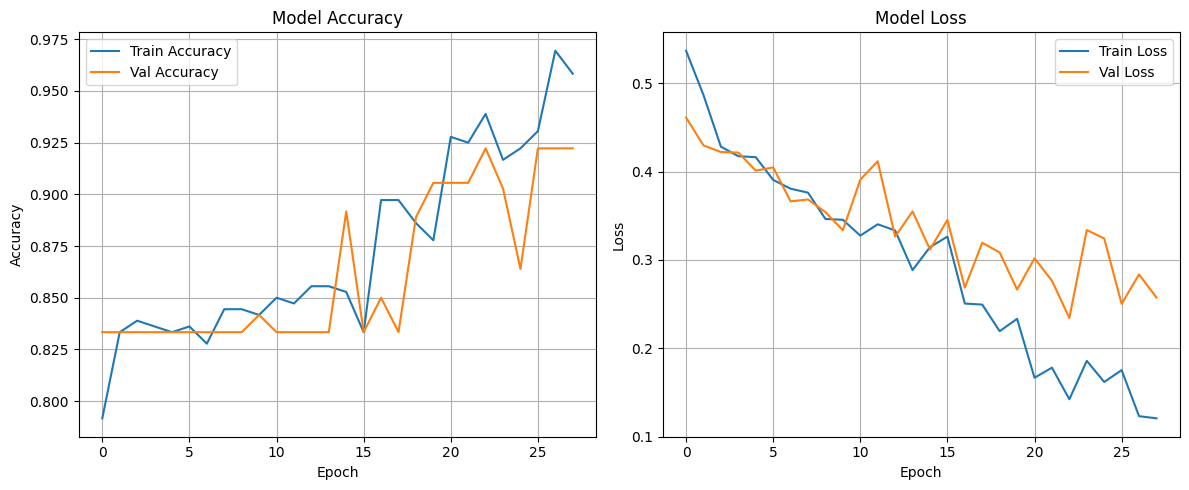

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Cell 12: Confusion Matrix on Test Set

30/30 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step


<Figure size 600x600 with 0 Axes>

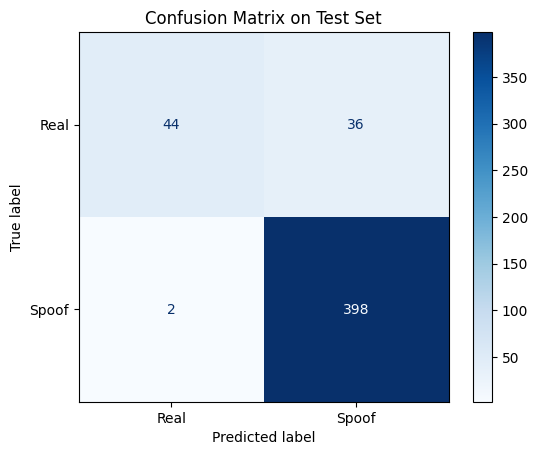

              precision    recall  f1-score   support

        Real       0.96      0.55      0.70        80
       Spoof       0.92      0.99      0.95       400

    accuracy                           0.92       480
   macro avg       0.94      0.77      0.83       480
weighted avg       0.92      0.92      0.91       480



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

# Get predictions on test set
y_pred_prob = model.predict(test_gen)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_labels

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Spoof'])

plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix on Test Set')
plt.show()

# Print metrics
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=['Real', 'Spoof']))

Testing

In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

# Load original model
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/ReplayAttack_Project/models/best_spoofing_model.h5',
    compile=False
)

# Re-compile (optional, but good)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fix input shape to match your data (20 frames)
fixed_input = Input(shape=(20, 224, 224, 3))  # FIXED TO 20
fixed_output = model(fixed_input)
fixed_model = Model(inputs=fixed_input, outputs=fixed_output)

# Copy weights
fixed_model.set_weights(model.get_weights())

# Compile and save as .keras
fixed_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
fixed_model.save('/content/drive/MyDrive/ReplayAttack_Project/models/fixed_spoofing_model.keras')
print("Fixed model saved with shape (20, 224, 224, 3)!")

Fixed model saved with shape (20, 224, 224, 3)!


In [1]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/ReplayAttack_Project'
print("Drive mounted. Ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Ready.


In [2]:
!pip uninstall mediapipe -y
!pip install mediapipe==0.10.14 --quiet
print("Mediapipe 0.10.14 installed.")

Found existing installation: mediapipe 0.10.14
Uninstalling mediapipe-0.10.14:
  Successfully uninstalled mediapipe-0.10.14
Mediapipe 0.10.14 installed.


In [4]:
from IPython.display import display, Javascript
from google.colab.output import eval_js

def test_camera_simple():
    js = Javascript('''
        async function checkCam() {
            try {
                const stream = await navigator.mediaDevices.getUserMedia({video: true});
                const tracks = stream.getTracks();
                tracks.forEach(track => track.stop());
                return "SUCCESS: Camera access granted!";
            } catch (err) {
                return "ERROR: " + err.name + " - " + err.message;
            }
        }
    ''')
    display(js)
    result = eval_js('checkCam()')
    print(result)

test_camera_simple()

<IPython.core.display.Javascript object>

SUCCESS: Camera access granted!


In [10]:
# =============================================================================
#   COMPLETE UPDATED LIVE ANTI-SPOOFING TEST (2025 version)
#   Features:
#     - Deep model threshold tunable (default 0.65)
#     - Blink detection
#     - Head movement detection
#     - Background consistency check (against static spoofs)
#     - Better feedback & error handling
# =============================================================================

import cv2
import numpy as np
import tensorflow as tf
import mediapipe as mp
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import time

# ────────────────────────────────────────────────
#   Load model
# ────────────────────────────────────────────────
model_path = '/content/drive/MyDrive/ReplayAttack_Project/models/fixed_spoofing_model.keras'
try:
    model = tf.keras.models.load_model(model_path)
    print("Model loaded successfully.")
except Exception as e:
    print(f"Model loading failed: {e}")
    raise

# ────────────────────────────────────────────────
#   MediaPipe Face Mesh
# ────────────────────────────────────────────────
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)
print("MediaPipe FaceMesh initialized.")

# ────────────────────────────────────────────────
#   Webcam capture function (JavaScript)
# ────────────────────────────────────────────────
def capture_frame(quality=0.8):
    js = Javascript('''
        async function captureFrame(quality) {
            const div = document.createElement('div');
            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(track => track.stop());
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('captureFrame({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    frame = cv2.imdecode(np.frombuffer(binary, np.uint8), cv2.IMREAD_COLOR)
    return frame

# ────────────────────────────────────────────────
#   Liveness helpers
# ────────────────────────────────────────────────
def detect_blink(landmarks):
    if not landmarks:
        return False
    # Left eye EAR approximation
    p33, p133, p159, p145 = landmarks[33], landmarks[133], landmarks[159], landmarks[145]
    vertical = np.linalg.norm([p159.x - p145.x, p159.y - p145.y])
    horizontal = np.linalg.norm([p33.x - p133.x, p33.y - p133.y])
    ear = vertical / horizontal
    return ear < 0.24  # typical blink threshold


def detect_head_movement(prev_lm, curr_lm, threshold=0.012):
    if not prev_lm or not curr_lm:
        return False
    # Nose tip (landmark 1) movement
    dx = abs(curr_lm[1].x - prev_lm[1].x)
    dy = abs(curr_lm[1].y - prev_lm[1].y)
    return (dx + dy) > threshold


def background_changed(prev_frame, curr_frame, threshold=7.5):
    if prev_frame is None:
        return False
    diff = cv2.absdiff(prev_frame, curr_frame)
    mean_diff = np.mean(diff)
    return mean_diff > threshold


# ────────────────────────────────────────────────
#   Live test function
# ────────────────────────────────────────────────
def live_test(
    num_frames=20,
    interval_sec=0.35,
    deep_threshold=0.65,          # ← tune this: 0.6–0.75 range recommended
    min_blinks=1,
    min_head_moves=2,
    min_bg_changes=3
):
    frames = []
    prev_frame_gray = None
    prev_landmarks = None

    blinks_detected = 0
    head_moves_detected = 0
    bg_changes_detected = 0

    print("\n" + "="*60)
    print("  LIVE ANTI-SPOOFING TEST")
    print("  → Look at camera, blink 2–4 times, gently move head left/right/up/down")
    print("  → Press 'Capture' button each time it appears")
    print("="*60 + "\n")

    for i in range(num_frames):
        print(f"  Capturing frame {i+1}/{num_frames} ...")
        frame = capture_frame()
        if frame is None:
            print("Capture failed.")
            return

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(frame_rgb)

        face_detected = bool(results.multi_face_landmarks)

        if face_detected:
            landmarks = results.multi_face_landmarks[0].landmark

            # Blink
            if detect_blink(landmarks):
                blinks_detected += 1
                print(f"    → Blink detected ({blinks_detected})")

            # Head movement
            if prev_landmarks and detect_head_movement(prev_landmarks, landmarks):
                head_moves_detected += 1
                print(f"    → Head movement detected ({head_moves_detected})")

            prev_landmarks = landmarks

        # Background change (convert to gray for faster comparison)
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if background_changed(prev_frame_gray, frame_gray):
            bg_changes_detected += 1
            print(f"    → Background change detected ({bg_changes_detected})")

        prev_frame_gray = frame_gray

        # Prepare for model
        frame_resized = cv2.resize(frame, (224, 224))
        frames.append(frame_resized / 255.0)

        time.sleep(interval_sec)

    # Pad / truncate
    while len(frames) < num_frames:
        frames.append(frames[-1])
    frames = np.array(frames[:num_frames])

    print("\n" + "-"*50)
    print("Liveness summary:")
    print(f"  Blinks: {blinks_detected}")
    print(f"  Head movements: {head_moves_detected}")
    print(f"  Background changes: {bg_changes_detected}")
    print("-"*50)

    # Stage 1: Strict liveness filter
    if (blinks_detected < min_blinks or
        head_moves_detected < min_head_moves or
        bg_changes_detected < min_bg_changes):
        print("RESULT: SPOOF DETECTED")
        print("Reason: Insufficient natural liveness signals (blinks / head motion / environment change)")
        return

    # Stage 2: Deep model prediction
    input_data = np.expand_dims(frames, axis=0)  # (1, 20, 224, 224, 3)
    pred = model.predict(input_data, verbose=0)[0][0]

    label = "SPOOF" if pred > deep_threshold else "REAL"
    confidence = max(pred, 1 - pred)

    print("\nFINAL RESULT:", label)
    print(f"Deep model raw score: {pred:.4f}")
    print(f"Confidence: {confidence:.3f}")
    print(f"Threshold used: {deep_threshold}")
    print(f"{'Real person accepted' if label == 'REAL' else 'Spoof rejected'}")

# ────────────────────────────────────────────────
#               RUN THE TEST
# ────────────────────────────────────────────────
live_test(
    deep_threshold=0.65,     # ← start here, increase to 0.7 / 0.75 if still too many false spoofs
    min_blinks=1,
    min_head_moves=2,
    min_bg_changes=3
)

Model loaded successfully.
MediaPipe FaceMesh initialized.

  LIVE ANTI-SPOOFING TEST
  → Look at camera, blink 2–4 times, gently move head left/right/up/down
  → Press 'Capture' button each time it appears

  Capturing frame 1/20 ...


<IPython.core.display.Javascript object>

  Capturing frame 2/20 ...


<IPython.core.display.Javascript object>

    → Head movement detected (1)
    → Background change detected (1)
  Capturing frame 3/20 ...


...

    → Head movement detected (12)
    → Background change detected (16)
  Capturing frame 19/20 ...


<IPython.core.display.Javascript object>

    → Head movement detected (13)
    → Background change detected (17)
  Capturing frame 20/20 ...


<IPython.core.display.Javascript object>

    → Background change detected (18)

--------------------------------------------------
Liveness summary:
  Blinks: 2
  Head movements: 13
  Background changes: 18
--------------------------------------------------

FINAL RESULT: SPOOF
Deep model raw score: 0.9909
Confidence: 0.991
Threshold used: 0.65
Spoof rejected
